In [1]:
!pip uninstall -y huggingface_hub diffusers transformers accelerate peft


!pip install huggingface_hub==0.20.0
!pip install accelerate==0.27.2  # ← Updated version
!pip install diffusers==0.25.0 transformers==4.36.0
!pip install peft==0.8.2  # ← Add compatible peft version
!pip install pytorch-fid torch torchvision pillow matplotlib tqdm

print("\n✓ All packages installed!")

Found existing installation: huggingface_hub 1.14.0
Uninstalling huggingface_hub-1.14.0:
  Successfully uninstalled huggingface_hub-1.14.0
Found existing installation: accelerate 0.27.2
Uninstalling accelerate-0.27.2:
  Successfully uninstalled accelerate-0.27.2
  Using cached huggingface_hub-0.20.0-py3-none-any.whl.metadata (12 kB)
Using cached huggingface_hub-0.20.0-py3-none-any.whl (329 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, which is not installed.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.20.0 which is incompatible.
sentence-transformers 5.4.1 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.20.0 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.20.0 which is incompatibl

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Update config - adjust path to where you extracted it
CONFIG = {
    'model_id': 'runwayml/stable-diffusion-v1-5',

    # Update this line:
    'data_dir': './data/CelebA-HQ-img',  # ← Changed from celeba_hq_256

    'output_dir': './outputs/part_b_pathway2_finetuned',
    # ... rest stays the same
}

# Verify
import glob
images = glob.glob(f"{CONFIG['data_dir']}/*.jpg") + glob.glob(f"{CONFIG['data_dir']}/*.png")
print(f"✓ Found {len(images)} images in {CONFIG['data_dir']}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Found 0 images in ./data/CelebA-HQ-img


In [3]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from diffusers import StableDiffusionPipeline, DDPMScheduler
from transformers import CLIPTextModel, CLIPTokenizer
from PIL import Image
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
import json
import random
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("✓ Imports successful")

/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
✓ Imports successful


/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [27]:
CONFIG = {
    'model_id': 'runwayml/stable-diffusion-v1-5',
    'data_dir': '/content/drive/MyDrive/CelebA-HQ-img',  # Your path from screenshot
    'output_dir': './outputs/part_b_pathway2_finetuned',
    'num_train': 2700,
    'num_test': 300,
    'image_size': 256,
    'num_epochs': 10,
    'batch_size': 4,
    'learning_rate': 1e-6,
    'gradient_accumulation_steps': 4,
    'num_generate': 300,
    'num_inference_steps': 50,
    'guidance_scale': 7.5,
    'prompts': [
        "a photo of a person's face, high quality",
        "portrait of a face, professional lighting",
        "close-up face photograph, realistic",
        "headshot portrait, neutral expression",
        "face photo, studio lighting",
        "a realistic portrait of a person, sharp focus",
        "front-facing face photograph, natural lighting",
        "professional headshot, clean background",
        "facial portrait, high resolution, detailed",
        "a clear photo of a human face, neutral background"
    ],
    'save_every': 2,
}

# Create directories
for subdir in ['', 'checkpoints', 'generated', 'test_set']:
    path = Path(CONFIG['output_dir']) / subdir if subdir else Path(CONFIG['output_dir'])
    path.mkdir(parents=True, exist_ok=True)

# Verify dataset
import glob
images = glob.glob(f"{CONFIG['data_dir']}/*.jpg") + glob.glob(f"{CONFIG['data_dir']}/*.png")
print(f"✓ Found {len(images)} images in {CONFIG['data_dir']}")

✓ Found 30060 images in /content/drive/MyDrive/CelebA-HQ-img


In [31]:
class FaceDataset(Dataset):
    def __init__(self, image_paths, prompts, image_size=512):
        self.image_paths = image_paths
        self.prompts = prompts
        self.image_size = image_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img = img.resize((self.image_size, self.image_size), Image.Resampling.LANCZOS)
        img_array = np.array(img).astype(np.float32) / 255.0
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)
        img_tensor = (img_tensor - 0.5) * 2.0
        prompt = random.choice(self.prompts)
        return {'image': img_tensor, 'prompt': prompt}

print("✓ Dataset class ready")

✓ Dataset class ready


In [32]:

data_path = Path(CONFIG['data_dir'])
all_images = []
for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
    all_images.extend(list(data_path.glob(f'*{ext}')))

print(f"Total images: {len(all_images)}")

random.shuffle(all_images)
train_images = all_images[:CONFIG['num_train']]
test_images = all_images[CONFIG['num_train']:CONFIG['num_train'] + CONFIG['num_test']]

print(f"Train: {len(train_images)}, Test: {len(test_images)}")


train_dataset = FaceDataset(train_images, CONFIG['prompts'], 512)
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True, num_workers=2, pin_memory=True)

print(f"✓ DataLoader ready: {len(train_loader)} batches/epoch")

Total images: 30060
Train: 2700, Test: 300
✓ DataLoader ready: 675 batches/epoch


In [33]:
test_dir = Path(CONFIG['output_dir']) / 'test_set'

for i, img_path in enumerate(tqdm(test_images, desc="Saving test set")):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((CONFIG['image_size'], CONFIG['image_size']), Image.Resampling.LANCZOS)
    img.save(test_dir / f"test_{i:04d}.png")

print(f"✓ Test set saved: {len(list(test_dir.glob('*.png')))} images")

Saving test set:   0%|          | 0/300 [00:00<?, ?it/s]

✓ Test set saved: 300 images


In [34]:
print("Loading Stable Diffusion v1.5...")

pipe = StableDiffusionPipeline.from_pretrained(
    CONFIG['model_id'],
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None
)

vae = pipe.vae.to(device)
text_encoder = pipe.text_encoder.to(device)
tokenizer = pipe.tokenizer
unet = pipe.unet.to(device)
unet = unet.float()  # ← train in float32 to avoid FP16 gradient error
noise_scheduler = DDPMScheduler.from_pretrained(CONFIG['model_id'], subfolder="scheduler")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.train()

print(f"✓ Model loaded: {sum(p.numel() for p in unet.parameters())/1e6:.1f}M params")

Loading Stable Diffusion v1.5...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✓ Model loaded: 859.5M params


In [35]:
optimizer = torch.optim.AdamW(unet.parameters(), lr=CONFIG['learning_rate'],
                              betas=(0.9, 0.999), weight_decay=1e-2)
print("✓ Optimizer ready")

✓ Optimizer ready


In [36]:
print("Starting fine-tuning...\n")
train_losses = []
epoch_losses = []

# Mixed precision scaler — prevents float16 overflow (root cause of NaN)
scaler = torch.cuda.amp.GradScaler()

optimizer.zero_grad()

for epoch in range(CONFIG['num_epochs']):
    epoch_loss = 0.0
    valid_batches = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']}")

    for batch_idx, batch in enumerate(pbar):
        images = batch['image'].to(device, dtype=torch.float16)
        prompts = batch['prompt']

        with torch.no_grad():
            latents = vae.encode(images).latent_dist.sample() * vae.config.scaling_factor

        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                 (latents.shape[0],), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        text_inputs = tokenizer(prompts, padding="max_length",
                               max_length=tokenizer.model_max_length,
                               truncation=True, return_tensors="pt")
        with torch.no_grad():
            text_embeddings = text_encoder(text_inputs.input_ids.to(device))[0]

        # Mixed precision forward pass
        with torch.cuda.amp.autocast():
            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embeddings).sample
            loss = F.mse_loss(noise_pred.float(), noise.float())

        # Skip NaN losses instead of corrupting weights
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  ⚠️  NaN loss at batch {batch_idx}, skipping...")
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()

        if (batch_idx + 1) % CONFIG['gradient_accumulation_steps'] == 0:
            # Gradient clipping — prevents exploding gradients → NaN weights
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        valid_batches += 1
        train_losses.append(loss.item())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = epoch_loss / max(valid_batches, 1)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1} - Avg Loss: {avg_loss:.4f}")

    if (epoch + 1) % CONFIG['save_every'] == 0:
        checkpoint_path = Path(CONFIG['output_dir']) / 'checkpoints' / f"unet_epoch_{epoch+1}.pt"
        torch.save({'epoch': epoch+1, 'unet_state_dict': unet.state_dict(), 'loss': avg_loss},
                  checkpoint_path)
        print(f"  ✓ Checkpoint saved | loss: {avg_loss:.4f}")

print("\n✓ Training complete!")


Starting fine-tuning...



Epoch 1/10:   0%|          | 0/675 [00:00<?, ?it/s]

Epoch 1 - Avg Loss: 0.1441


Epoch 2/10:   0%|          | 0/675 [00:00<?, ?it/s]

Epoch 2 - Avg Loss: 0.1442
  ✓ Checkpoint saved | loss: 0.1442


...

Epoch 8 - Avg Loss: 0.1447
  ✓ Checkpoint saved | loss: 0.1447


Epoch 9/10:   0%|          | 0/675 [00:00<?, ?it/s]

Epoch 9 - Avg Loss: 0.1450


Epoch 10/10:   0%|          | 0/675 [00:00<?, ?it/s]

Epoch 10 - Avg Loss: 0.1470
  ✓ Checkpoint saved | loss: 0.1470

✓ Training complete!


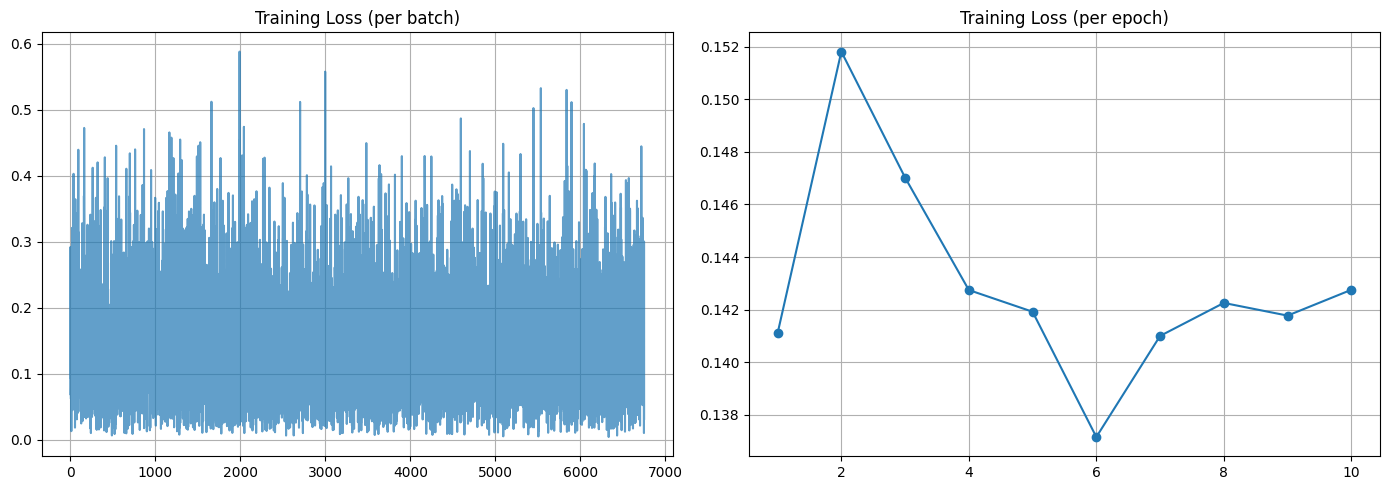

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, alpha=0.7)
axes[0].set_title('Training Loss (per batch)')
axes[0].grid(True)
axes[1].plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
axes[1].set_title('Training Loss (per epoch)')
axes[1].grid(True)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/training_loss.png", dpi=150)
plt.show()

In [17]:
unet.eval()
unet = unet.float()


pipe.vae = pipe.vae.float()
pipe.text_encoder = pipe.text_encoder.float()
pipe.unet = unet

finetuned_pipe = pipe
finetuned_pipe.safety_checker = None
finetuned_pipe.enable_attention_slicing()


print("Checking UNet output for NaN/Inf...")
with torch.no_grad():
    _dummy_latent = torch.randn(1, 4, 64, 64, device=device, dtype=torch.float32)
    _dummy_t = torch.tensor([500], device=device)
    _dummy_enc = pipe.text_encoder(
        pipe.tokenizer(["test"], return_tensors="pt", padding="max_length",
                       max_length=pipe.tokenizer.model_max_length,
                       truncation=True).input_ids.to(device)
    )[0]
    _out = unet(_dummy_latent, _dummy_t, encoder_hidden_states=_dummy_enc).sample
    if torch.isnan(_out).any() or torch.isinf(_out).any():
        print("⚠️  WARNING: UNet producing NaN/Inf — model may be corrupted")
    else:
        print(f"✓ UNet output healthy | range: [{_out.min():.2f}, {_out.max():.2f}]")

print("✓ Pipeline ready")


Checking UNet output for NaN/Inf...
✓ UNet output healthy | range: [-3.68, 3.54]
✓ Pipeline ready


Running sanity check on pipeline...


  0%|          | 0/20 [00:00<?, ?it/s]

Test image mean pixel value: 100.81
✅ Sanity check passed! Pipeline is working correctly.


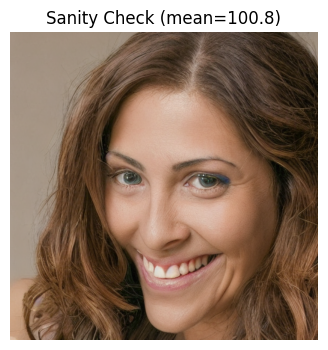

In [18]:

print("Running sanity check on pipeline...")

def is_black_image(img, threshold=10):
    """Returns True if image is mostly black (mean pixel < threshold)"""
    return np.array(img).mean() < threshold


test_generator = torch.Generator(device=device).manual_seed(SEED)
with torch.no_grad():
    test_output = finetuned_pipe(
        prompt=CONFIG['prompts'][0],
        num_inference_steps=20,   # fewer steps just for the check
        guidance_scale=CONFIG['guidance_scale'],
        generator=test_generator,
        height=512, width=512
    )

test_img = test_output.images[0].convert('RGB')
mean_val = np.array(test_img).mean()
print(f"Test image mean pixel value: {mean_val:.2f}")

if is_black_image(test_img):
    print(" BLACK IMAGE DETECTED — applying emergency fix")

    finetuned_pipe.vae = finetuned_pipe.vae.float()
    finetuned_pipe.unet = finetuned_pipe.unet.float()
    finetuned_pipe.text_encoder = finetuned_pipe.text_encoder.float()

    # Retry
    with torch.no_grad():
        test_output = finetuned_pipe(
            prompt=CONFIG['prompts'][0],
            num_inference_steps=20,
            guidance_scale=CONFIG['guidance_scale'],
            generator=torch.Generator(device=device).manual_seed(SEED),
            height=512, width=512
        )
    test_img = test_output.images[0].convert('RGB')
    mean_val = np.array(test_img).mean()
    print(f"After fix — mean pixel value: {mean_val:.2f}")

    if is_black_image(test_img):
        print("Still black. Check GPU memory or restart runtime and rerun from Step 12.")
    else:
        print("Fix worked! Proceed to generation.")
else:
    print("Sanity check passed! Pipeline is working correctly.")

# Show the test image
plt.figure(figsize=(4,4))
plt.imshow(test_img)
plt.title(f'Sanity Check (mean={mean_val:.1f})')
plt.axis('off')
plt.show()
# ──────────────────────────────────────────────────────────────────────────────


In [37]:
gen_dir = Path(CONFIG['output_dir']) / 'generated'
gen_dir.mkdir(parents=True, exist_ok=True)

for i in tqdm(range(CONFIG['num_generate']), desc="Generating"):
    prompt = CONFIG['prompts'][i % len(CONFIG['prompts'])]
    generator = torch.Generator(device=device).manual_seed(SEED + i)

    with torch.no_grad():
        output = finetuned_pipe(
            prompt=prompt,
            num_inference_steps=CONFIG['num_inference_steps'],
            guidance_scale=CONFIG['guidance_scale'],
            generator=generator,
            height=512,
            width=512
        )

    image = output.images[0].convert('RGB')
    image = image.resize((CONFIG['image_size'], CONFIG['image_size']), Image.Resampling.LANCZOS)
    image.save(gen_dir / f"generated_{i:04d}.png")

print(f"✓ Generated {len(list(gen_dir.glob('*.png')))} images")


Generating:   0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

✓ Generated 300 images


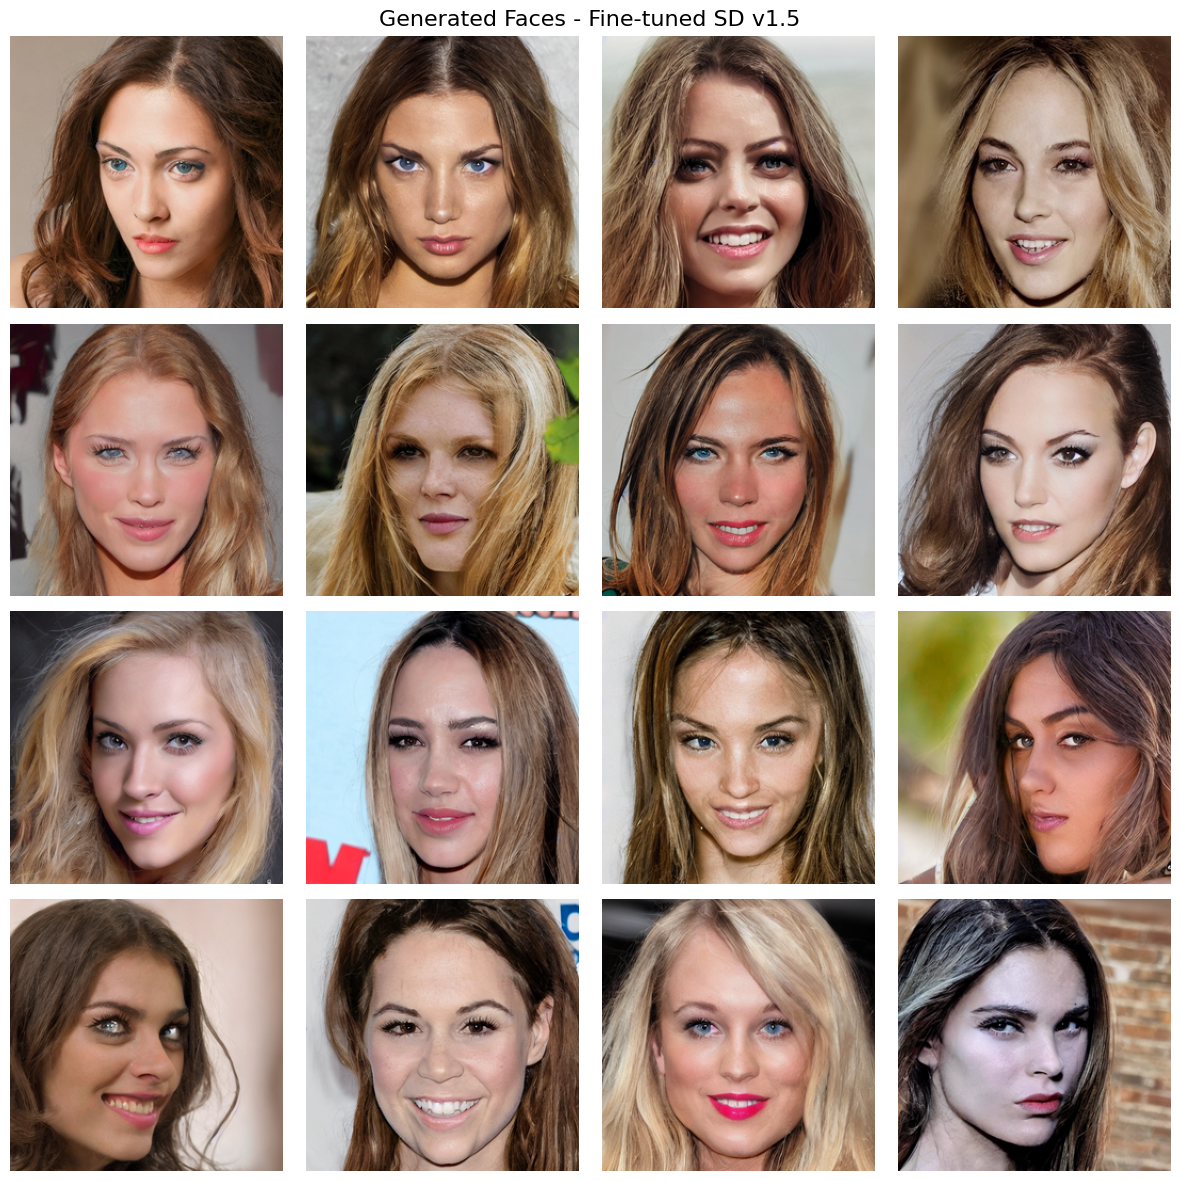

In [38]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Generated Faces - Fine-tuned SD v1.5', fontsize=16)

for i, ax in enumerate(axes.flat):
    img = Image.open(gen_dir / f"generated_{i:04d}.png")
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/sample_grid.png", dpi=150)
plt.show()

In [39]:
from pytorch_fid import fid_score

fid = fid_score.calculate_fid_given_paths(
    [str(Path(CONFIG['output_dir']) / 'test_set'),
     str(Path(CONFIG['output_dir']) / 'generated')],
    batch_size=50,
    device=device,
    dims=2048
)

print(f"\nFID Score: {fid:.4f}")

100%|██████████| 6/6 [00:01<00:00,  4.37it/s]



FID Score: 78.8785
